Original Data Shape: (4424, 35)
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


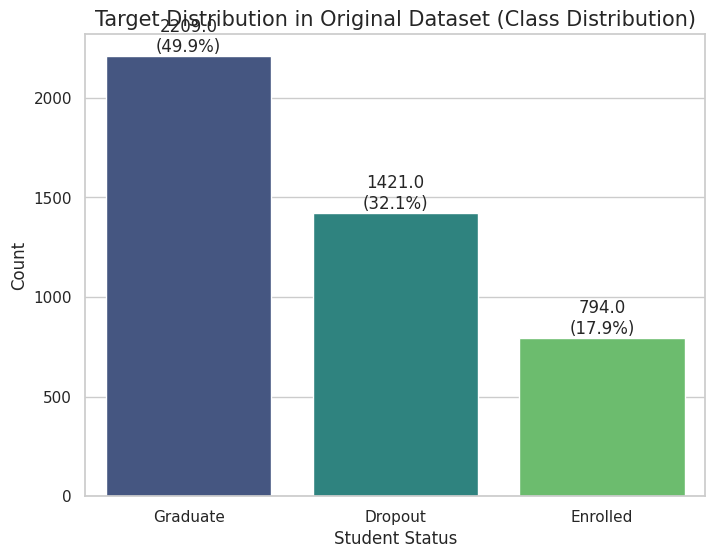

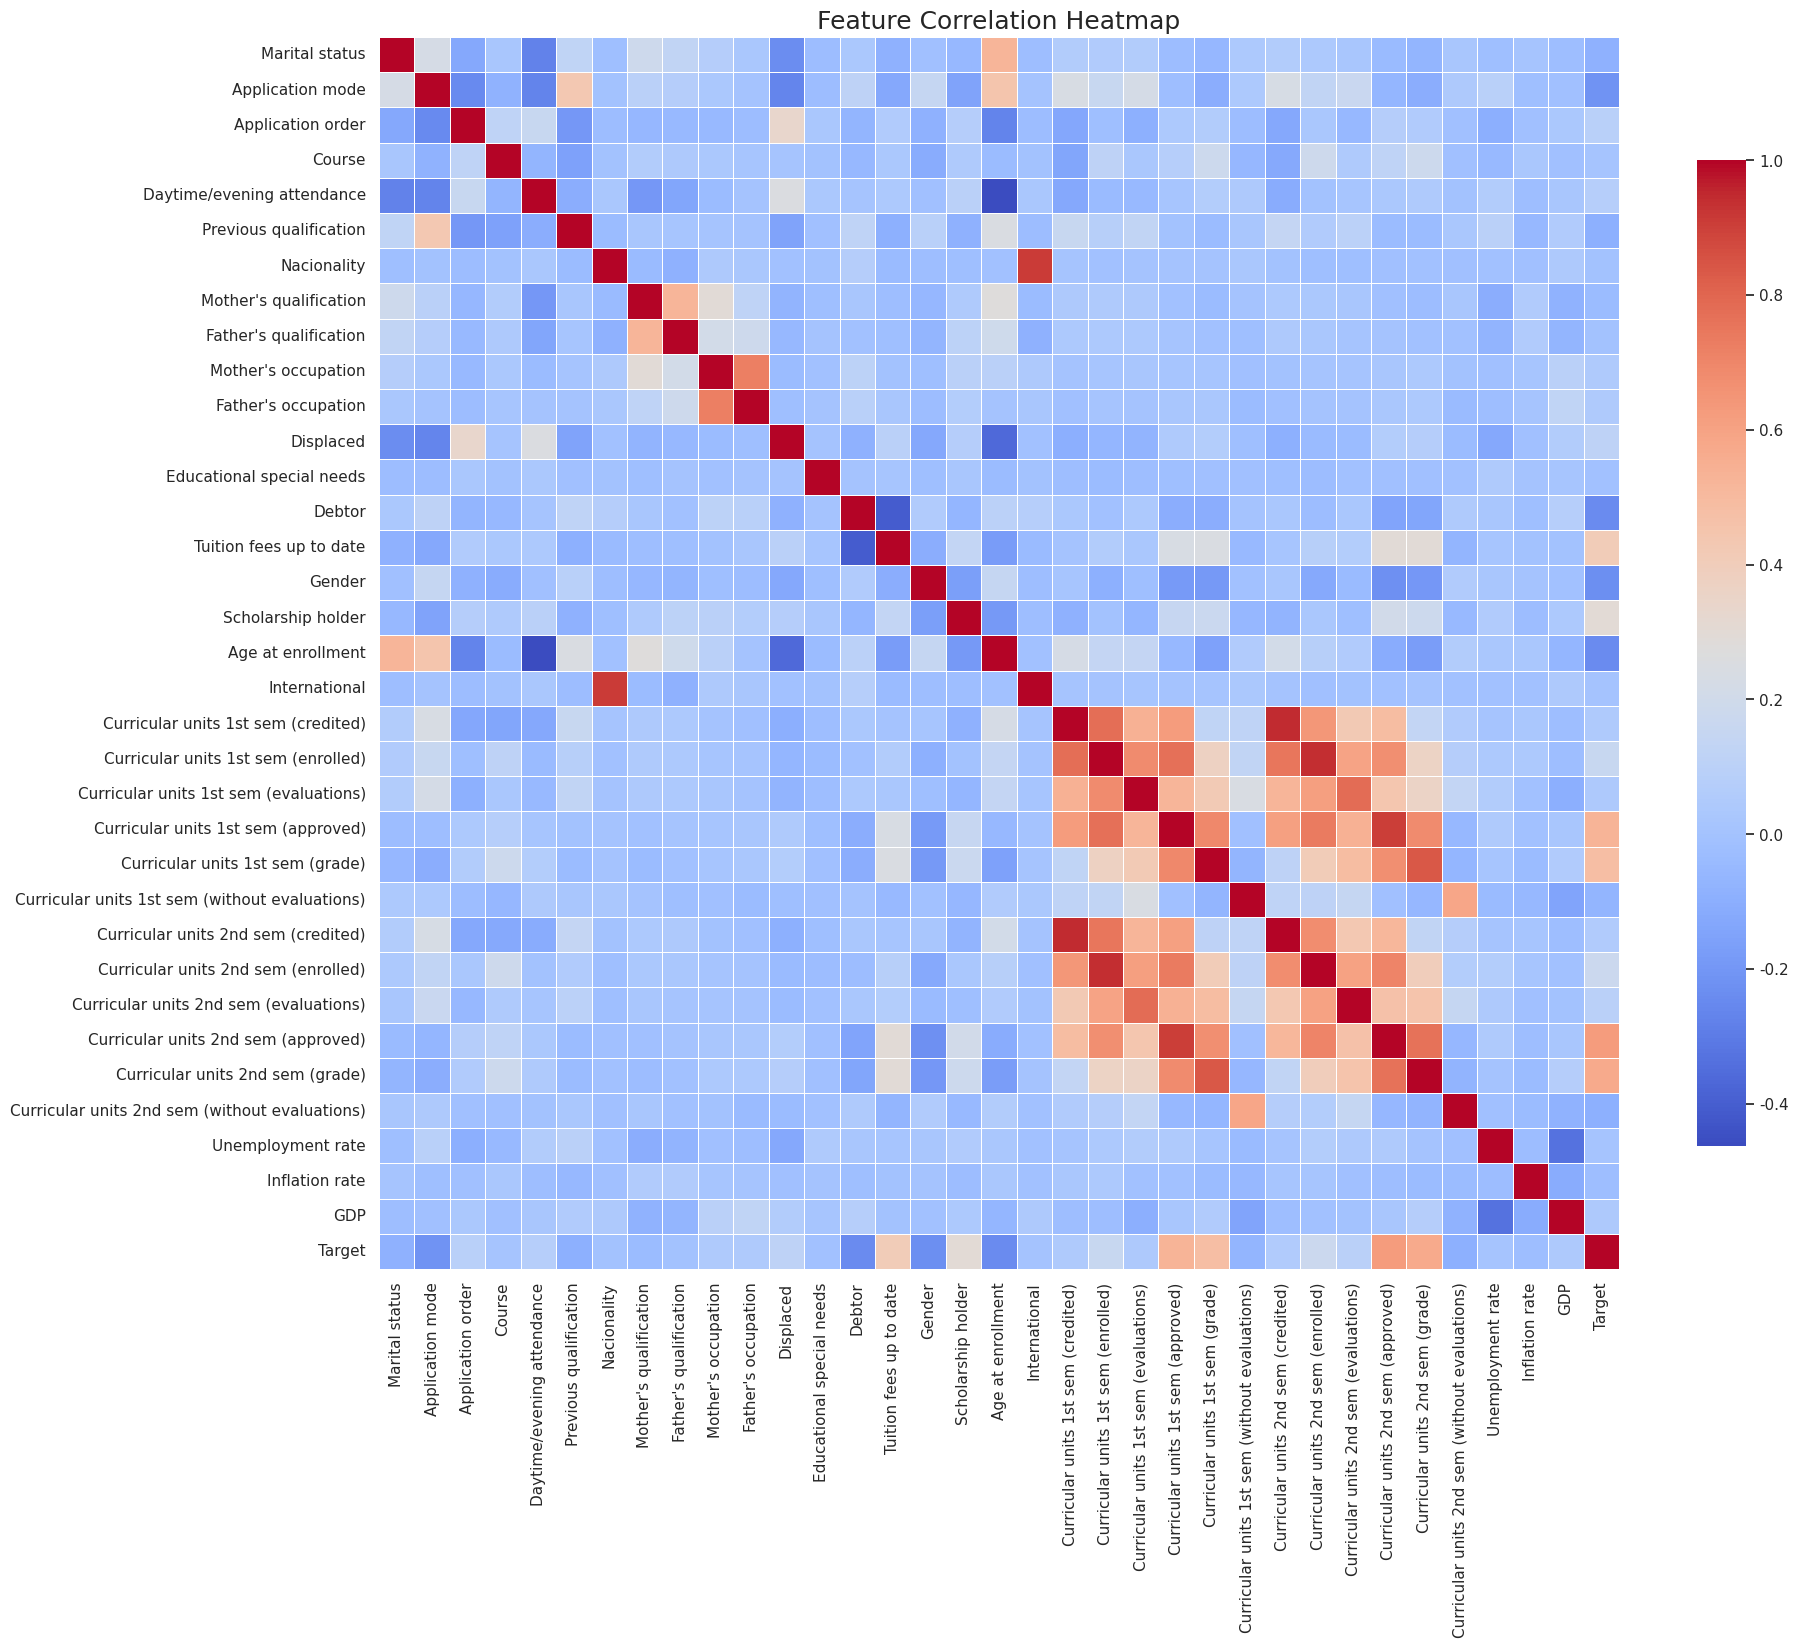

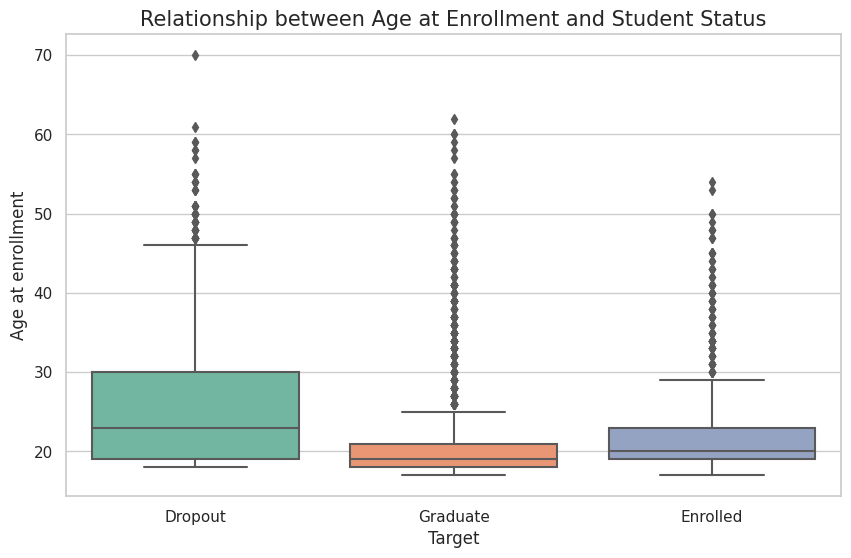

Label Encoding Mapping: {'Dropout': 0, 'Graduate': 1}

Data Preprocessing Completed!
Training set size: (2904, 34), Test set size: (726, 34)

Starting Training and Evaluation (with 10-Fold Cross-Validation)...
--------------------------------------------------
[Decision Tree]
  - 10-Fold CV Mean Accuracy: 0.8726
  - Test Set Accuracy: 0.8636
  - F1 Score: 0.8923
[Naive Bayes]
  - 10-Fold CV Mean Accuracy: 0.8402
  - Test Set Accuracy: 0.8567
  - F1 Score: 0.8884
[Random Forest]
  - 10-Fold CV Mean Accuracy: 0.9105
  - Test Set Accuracy: 0.8926
  - F1 Score: 0.9156


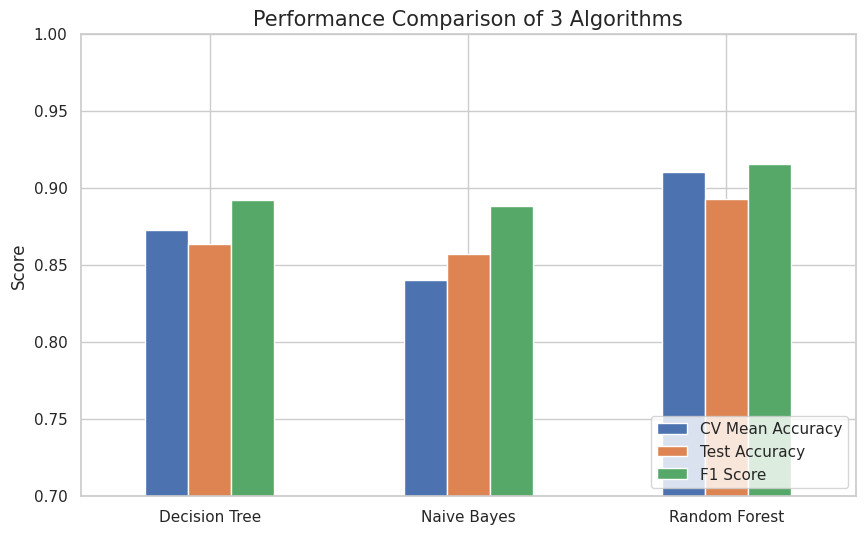

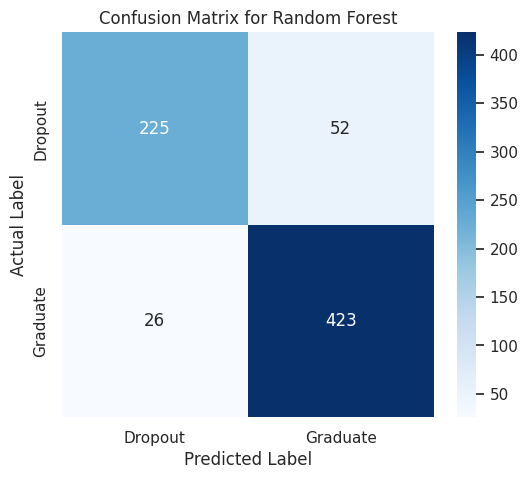

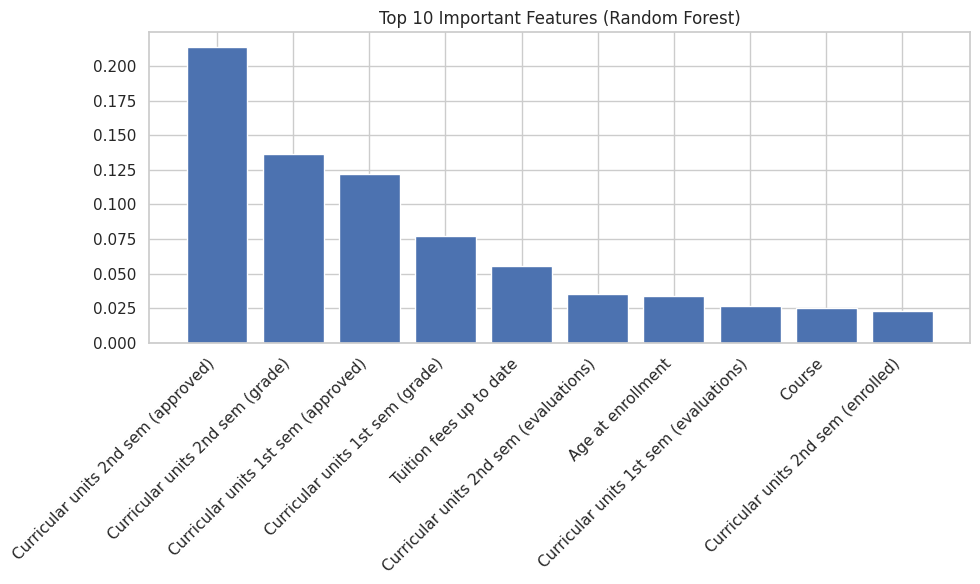

In [1]:
# ==========================================
# 1. Import Necessary Libraries
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Import Classification Algorithms
# 1. Decision Tree (Corresponds to J48/C4.5 requirement in the coursework)
from sklearn.tree import DecisionTreeClassifier 
# 2. Naive Bayes (Corresponds to Naive Bayes requirement)
from sklearn.naive_bayes import GaussianNB 
# 3. Random Forest (Used as the optimized model for performance comparison)
from sklearn.ensemble import RandomForestClassifier

# Set plotting style
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 2. Data Loading and Exploration 
# ==========================================
# Load the dataset
df = pd.read_csv('/kaggle/input/higher-education-predictors-of-student-retention/dataset.csv')

print("Original Data Shape:", df.shape)
# Check the distribution of the target variable
print(df['Target'].value_counts())

# ==========================================
# 2.2 Exploratory Data Analysis (Visualization)
# ==========================================

# Configure plot style for academic reporting
sns.set(style="whitegrid", context="notebook")
# Ensure minus signs are displayed correctly
plt.rcParams['axes.unicode_minus'] = False 

# --- Figure 1: Target Class Distribution ---
# Purpose: Display the proportion of each class to demonstrate data distribution analysis
plt.figure(figsize=(8, 6))

# Plot count plot
ax = sns.countplot(x='Target', data=df, palette='viridis', order=df['Target'].value_counts().index)

# Add counts and percentages on the bars to enhance professional presentation
total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(f'{y}\n({percentage})', (x, y), ha='center', va='bottom', fontsize=12)

plt.title('Target Distribution in Original Dataset (Class Distribution)', fontsize=15)
plt.xlabel('Student Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

# --- Figure 2: Feature Correlation Heatmap ---
# Purpose: Visualize linear relationships between features to identify key predictors
# Note: Encode the Target variable temporarily to include it in the correlation matrix
df_temp = df.copy()
le = LabelEncoder()
df_temp['Target'] = le.fit_transform(df_temp['Target'])

# Calculate correlation matrix
plt.figure(figsize=(20, 16)) # Larger figure size for visibility of 30+ features
# numeric_only=True ensures compatibility with newer pandas versions
corr_matrix = df_temp.corr(numeric_only=True) 

# Plot heatmap
# annot=False: Hide numbers to avoid clutter due to small cell size
# cmap='coolwarm': Red indicates positive correlation, Blue indicates negative
sns.heatmap(corr_matrix, annot=False, fmt=".2f", cmap='coolwarm', 
            linewidths=0.5, cbar_kws={"shrink": .8})

plt.title('Feature Correlation Heatmap', fontsize=18)
plt.show()

# --- Figure 3 (Optional Bonus): Key Feature vs. Target ---
# Example: Analyzing the impact of "Age at enrollment" on Dropout/Graduate status
plt.figure(figsize=(10, 6))
sns.boxplot(x='Target', y='Age at enrollment', data=df, palette="Set2")
plt.title('Relationship between Age at Enrollment and Student Status', fontsize=15)
plt.show()


# ==========================================
# 3. Data Preprocessing 
# ==========================================
# 3.1 Convert to Binary Classification Task
# Focus on "Graduate" and "Dropout", excluding "Enrolled"
df = df[df['Target'] != 'Enrolled']

# 3.2 Label Encoding
# Encode Target labels to integers (e.g., Dropout -> 0, Graduate -> 1)
label_encoder = LabelEncoder()
df['Target'] = label_encoder.fit_transform(df['Target'])
print("Label Encoding Mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# 3.3 Separate Features and Target
X = df.drop('Target', axis=1)
y = df['Target']

# 3.4 Feature Standardization (Critical Step)
# Algorithms like Naive Bayes are sensitive to feature scaling; standardization is required.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# Convert back to DataFrame to preserve column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 3.5 Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("\nData Preprocessing Completed!")
print(f"Training set size: {X_train.shape}, Test set size: {X_test.shape}")

# ==========================================
# 4. Model Construction and 10-Fold Cross-Validation 
# ==========================================

# Define the three classifiers
classifiers = {
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=10), # Limit depth to prevent overfitting
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

results = {}

print("\nStarting Training and Evaluation (with 10-Fold Cross-Validation)...")
print("-" * 50)

for name, clf in classifiers.items():
    # A. 10-Fold Cross-Validation (Strictly required by the grading criteria)
    # cv=10 performs 10-fold CV
    cv_scores = cross_val_score(clf, X_train, y_train, cv=10, scoring='accuracy')
    
    # B. Final Evaluation on the Independent Test Set
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    
    # C. Record Metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        "CV Mean Accuracy": cv_scores.mean(),
        "Test Accuracy": acc,
        "F1 Score": f1,
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }
    
    print(f"[{name}]")
    print(f"  - 10-Fold CV Mean Accuracy: {cv_scores.mean():.4f}")
    print(f"  - Test Set Accuracy: {acc:.4f}")
    print(f"  - F1 Score: {f1:.4f}")

# ==========================================
# 5. Result Comparison and Visualization 
# ==========================================

# 5.1 Performance Comparison Bar Chart
metrics_df = pd.DataFrame(results).T[['CV Mean Accuracy', 'Test Accuracy', 'F1 Score']]
metrics_df.plot(kind='bar', figsize=(10, 6))
plt.title('Performance Comparison of 3 Algorithms', fontsize=15)
plt.ylabel('Score')
plt.ylim(0.7, 1.0) # Set y-axis limits to highlight differences
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

# 5.2 Confusion Matrix Heatmap (For the best model: Random Forest)
best_model_name = "Random Forest"
cm = results[best_model_name]["Confusion Matrix"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix for {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

# 5.3 Feature Importance Analysis (Bonus Analysis Point)
rf_model = classifiers["Random Forest"]
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Display the Top 10 most important features
top_n = 10
plt.figure(figsize=(10, 6))
plt.title("Top 10 Important Features (Random Forest)")
plt.bar(range(top_n), importances[indices[:top_n]], align="center")
plt.xticks(range(top_n), [X.columns[i] for i in indices[:top_n]], rotation=45, ha='right')
plt.tight_layout()
plt.show()